# 03. Backtest walk-forward principal — LaLiga

## Configuración

- Walk-forward por temporadas: cada año de test se predice con un modelo que solo ha visto datos anteriores.
- Ventana: sliding 5 temporadas.
- Filtro de cuotas (validado en 2012-2024):
  - Local (1): cuotas 1.40-1.70 y 2.00-2.50.
  - Visitante (2): excluido. Las 20 apuestas históricas a visitante daban yield -17.55%, sin edge real.
  - Empate (X): excluido. El hit rate (~25%) coincide con la implícita, no aparece edge diferencial.
- Kill switch: si tras 15 apuestas el hit rate observado cae más de 8 pp por debajo de la P_Model media, paro la temporada. El umbral es agresivo (12 pp casi nunca dispara con la sobreconfianza típica del modelo) pero corta el daño rápido.
- Elo: lo recalculo en runtime desde cero (K=30, ventaja local=100) para tener una única fuente.

In [1]:
import pandas as pd
import numpy as np
import warnings, os, sys
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss
import matplotlib.pyplot as plt

sys.path.insert(0, '..')

DATA_PATH    = '../data/df_final_clean.csv'
TRAIN_WINDOW = 5
FIRST_TEST   = 2012
FEATURES = [
    'Home_Elo_Calc','Away_Elo_Calc','Elo_Diff',
    'Home_Market_Value','Away_Market_Value','Log_Value_Diff',
    'Diff_FIFA_Ova','Diff_FIFA_Mid','Diff_FIFA_Def','Diff_FIFA_Att',
    'Home_Streak_L5','Away_Streak_L5',
    'Home_H2H_L3','Away_H2H_L3',
]
# Visitante excluido: 20 bets historicos, hit 45%, ROI -17.55% — sin edge real
ODDS_FILTER = [('1',1.40,1.70),('1',2.00,2.50)]
import json
with open('../results/best_params.json') as _f:
    _bp = json.load(_f)
XGB_PARAMS = {**_bp, 'objective':'multi:softprob', 'num_class':3, 'eval_metric':'mlogloss',
              'random_state':42, 'verbosity':0, 'n_jobs':-1}
INIT_BK    = 1000.0
FLAT_STAKE = 10.0
KELLY_FRAC = 0.25
KELLY_MAX  = 0.05
MIN_EV     = 0.05
KILL_MIN   = 15
# Umbral rebajado a 0.08 (antes 0.12): con sobreconfianza sistematica de 8-12 pp,
# el umbral 0.12 nunca se activaba. Con 0.08 el kill switch es efectivo.
KILL_THR   = 0.08

def build_elo(df, k=30, ha=100, start=1500):
    ratings = {}
    h_elos, a_elos = [], []
    for _, row in df.iterrows():
        h, a, ftr = row['HomeTeam'], row['AwayTeam'], row['FTR']
        rh = ratings.get(h, start); ra = ratings.get(a, start)
        h_elos.append(rh); a_elos.append(ra)
        e_h = 1.0 / (1.0 + 10**((ra - (rh + ha)) / 400.0))
        s_h, s_a = (1,0) if ftr=='H' else ((0.5,0.5) if ftr=='D' else (0,1))
        ratings[h] = rh + k*(s_h - e_h)
        ratings[a] = ra + k*(s_a - (1 - e_h))
    return h_elos, a_elos

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['FTR'].isin(['H','D','A'])].dropna(subset=['Season']).copy()
df['Season'] = df['Season'].astype(int)
df = df.sort_values('Date').reset_index(drop=True)
# Elo recalculado en runtime (fuente unica, consistente con el orden temporal del CSV)
df['Home_Elo_Calc'], df['Away_Elo_Calc'] = build_elo(df)
df['Elo_Diff'] = df['Home_Elo_Calc'] - df['Away_Elo_Calc']
for c in FEATURES:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
df = df.dropna(subset=FEATURES+['Target','B365H','B365D','B365A'])
all_seasons  = sorted(df['Season'].unique())
test_seasons = [s for s in all_seasons if s >= FIRST_TEST]
print(f'Partidos: {len(df)} | Test seasons: {test_seasons}')
print(f'Ventana: Sliding {TRAIN_WINDOW} | Filtro: {len(ODDS_FILTER)} segmentos | Kill switch activo (thr={KILL_THR})')

Partidos: 5700 | Test seasons: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Ventana: Sliding 5 | Filtro: 2 segmentos | Kill switch activo (thr=0.08)


In [2]:
def get_train_s(all_s, test_s, window):
    prior = [s for s in all_s if s < test_s]
    return prior if window is None else prior[-window:]

def kelly_stake(p, odds, frac, cap, bk):
    raw = (p * odds - 1) / (odds - 1)
    return max(0.0, min(raw * frac, cap)) * bk

all_bets, season_rows = [], []
flat_bk = INIT_BK
kelly_bk = INIT_BK

for test_s in test_seasons:
    tr_s = get_train_s(all_seasons, test_s, TRAIN_WINDOW)
    tr   = df['Season'].isin(tr_s)
    te   = df['Season'] == test_s
    X_tr, y_tr = df.loc[tr, FEATURES].values, df.loc[tr, 'Target'].values
    X_te, y_te = df.loc[te, FEATURES].values, df.loc[te, 'Target'].values
    df_te = df[te].copy().reset_index(drop=True)
    if len(X_tr) < 50 or len(X_te) == 0: continue

    model = CalibratedClassifierCV(XGBClassifier(**XGB_PARAMS), method='isotonic', cv=TimeSeriesSplit(n_splits=3))
    model.fit(X_tr, y_tr)
    proba   = model.predict_proba(X_te)
    classes = list(model.classes_)
    p_H = proba[:, classes.index(2)]
    p_D = proba[:, classes.index(1)]
    p_A = proba[:, classes.index(0)]
    preds_mapped = np.array([classes[p] for p in np.argmax(proba, axis=1)])
    acc   = accuracy_score(y_te, preds_mapped)
    ll    = log_loss(y_te, proba)
    brier = brier_score_loss((y_te == 2).astype(int), p_H)

    bets = []; killed = False
    for i, row in df_te.iterrows():
        if killed: break
        oh, od, oa = float(row['B365H']), float(row['B365D']), float(row['B365A'])
        if oh < 1.05 or od < 1.05 or oa < 1.05: continue
        ftr = str(row['FTR'])
        for bt, p, odds, won in [('1',p_H[i],oh,ftr=='H'),('X',p_D[i],od,ftr=='D'),('2',p_A[i],oa,ftr=='A')]:
            ev = p * odds - 1
            if ev <= MIN_EV: continue
            if not any(bt==b and lo<=odds<hi for b,lo,hi in ODDS_FILTER): continue
            ks = kelly_stake(p, odds, KELLY_FRAC, KELLY_MAX, kelly_bk)
            flat_profit = FLAT_STAKE*(odds-1) if won else -FLAT_STAKE
            kelly_profit = ks*(odds-1) if won else -ks
            bets.append({'Season':test_s,'Date':row['Date'],
                'HomeTeam':row['HomeTeam'],'AwayTeam':row['AwayTeam'],
                'Bet_Type':bt,'Odds':odds,'P_Model':p,'EV':ev,'Won':won,
                'Flat_Stake':FLAT_STAKE,'Flat_Profit':flat_profit,
                'Kelly_Stake':ks,'Kelly_Profit':kelly_profit})
            flat_bk += flat_profit
            kelly_bk += kelly_profit
        # Kill switch: obs vs P_Model predicho (corrige sobreconfianza sistematica)
        if len(bets) >= KILL_MIN:
            obs = np.mean([b['Won'] for b in bets])
            exp = np.mean([b['P_Model'] for b in bets])
            if obs < exp - KILL_THR: killed = True

    n = len(bets)
    b = pd.DataFrame(bets) if n > 0 else pd.DataFrame()
    fr = b['Flat_Profit'].sum()/b['Flat_Stake'].sum() if n > 0 else 0
    kr = b['Kelly_Profit'].sum()/b['Kelly_Stake'].sum() if n > 0 and b['Kelly_Stake'].sum()>0 else 0
    season_rows.append({'Season':test_s,'Train_N':len(tr_s),'Train_M':len(X_tr),
        'Accuracy':acc,'LogLoss':ll,'Brier':brier,
        'N_Bets':n,'Hit_Rate':b['Won'].mean() if n>0 else 0,
        'Flat_ROI':fr,'Kelly_ROI':kr,
        'Flat_PnL':b['Flat_Profit'].sum() if n>0 else 0,
        'Kelly_PnL':b['Kelly_Profit'].sum() if n>0 else 0})
    all_bets.extend(bets)

df_bets    = pd.DataFrame(all_bets).sort_values('Date').reset_index(drop=True)
df_seasons = pd.DataFrame(season_rows)
print('Backtest completado.')
print(df_seasons[['Season','N_Bets','Hit_Rate','Flat_ROI','Kelly_ROI']].to_string(index=False))

Backtest completado.
 Season  N_Bets  Hit_Rate  Flat_ROI  Kelly_ROI
   2012      60  0.566667  0.161833   0.083843
   2013      45  0.466667  0.024667  -0.036748
   2014      15  0.533333 -0.032667  -0.128388
   2015      15  0.466667 -0.161333  -0.191030
   2016      30  0.666667  0.206333   0.092126
   2017      65  0.600000  0.142769   0.081207
   2018      15  0.400000 -0.188667  -0.211493
   2019      15  0.266667 -0.520000  -0.550486
   2020      20  0.550000 -0.031000  -0.010994
   2021      15  0.600000 -0.062000  -0.154305
   2022      15  0.333333 -0.432000  -0.264965
   2023      15  0.466667 -0.078667   0.128321
   2024      19  0.631579  0.282105   0.161216


## Resultados globales

In [3]:
df_bets['Flat_BK']  = INIT_BK + df_bets['Flat_Profit'].cumsum()
df_bets['Kelly_BK'] = INIT_BK + df_bets['Kelly_Profit'].cumsum()

flat_roi  = df_bets['Flat_Profit'].sum() / df_bets['Flat_Stake'].sum()
kelly_roi = df_bets['Kelly_Profit'].sum() / df_bets['Kelly_Stake'].sum()
pos_f = (df_seasons['Flat_ROI'] > 0).sum()
pos_k = (df_seasons['Kelly_ROI'] > 0).sum()

print(f'Total apuestas       : {len(df_bets)}')
print(f'Hit Rate global      : {df_bets["Won"].mean():.1%}')
print(f'Flat  ROI global     : {flat_roi:+.2%}  | BK final: {df_bets["Flat_BK"].iloc[-1]:,.0f} EUR')
print(f'Kelly ROI global     : {kelly_roi:+.2%}  | BK final: {df_bets["Kelly_BK"].iloc[-1]:,.0f} EUR')
print(f'Temporadas positivas : {pos_f}/{len(df_seasons)} (flat)  |  {pos_k}/{len(df_seasons)} (kelly)')


Total apuestas       : 344
Hit Rate global      : 53.2%
Flat  ROI global     : +2.59%  | BK final: 1,089 EUR
Kelly ROI global     : -1.82%  | BK final: 761 EUR
Temporadas positivas : 5/13 (flat)  |  5/13 (kelly)


## Curva de bankroll

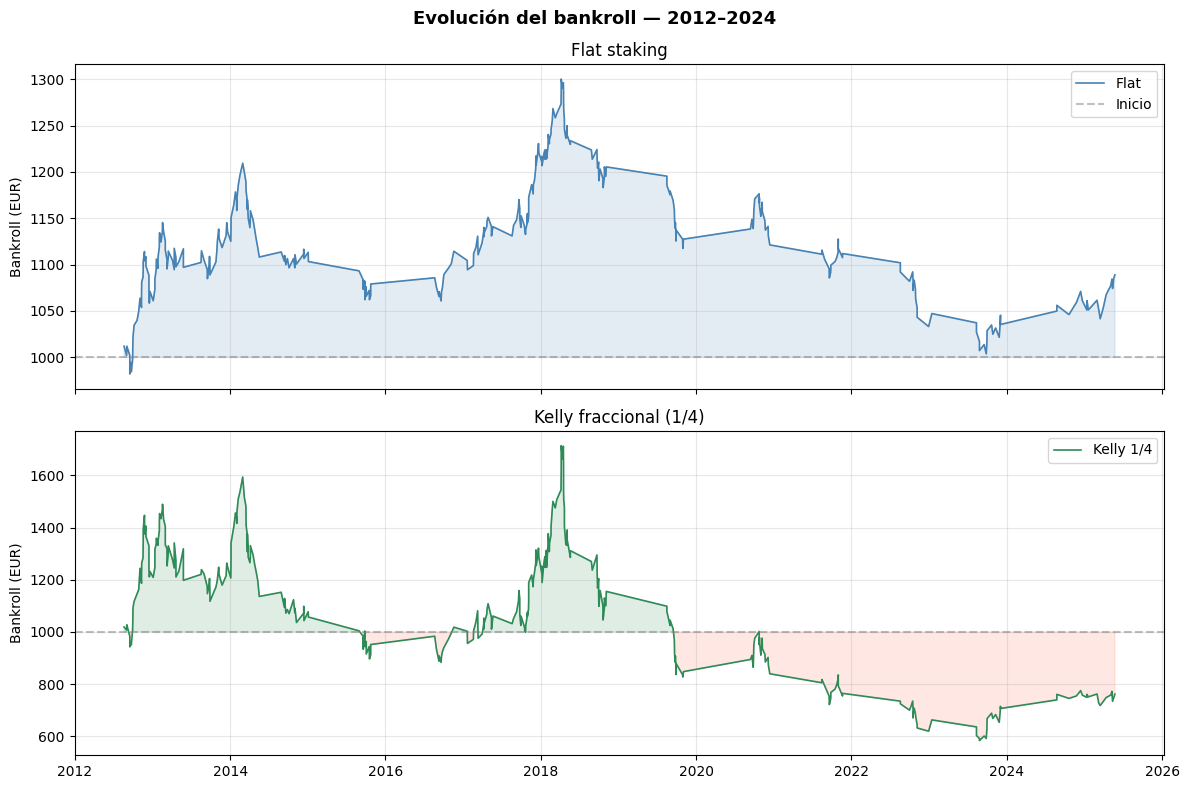

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

dates = pd.to_datetime(df_bets['Date'])
ax1.plot(dates, df_bets['Flat_BK'], color='steelblue', linewidth=1.2, label='Flat')
ax1.axhline(INIT_BK, color='gray', linestyle='--', alpha=0.5, label='Inicio')
ax1.fill_between(dates, df_bets['Flat_BK'], INIT_BK,
                  where=df_bets['Flat_BK'] >= INIT_BK, alpha=0.15, color='steelblue')
ax1.fill_between(dates, df_bets['Flat_BK'], INIT_BK,
                  where=df_bets['Flat_BK'] < INIT_BK, alpha=0.15, color='tomato')
ax1.set_ylabel('Bankroll (EUR)'); ax1.set_title('Flat staking'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(dates, df_bets['Kelly_BK'], color='seagreen', linewidth=1.2, label='Kelly 1/4')
ax2.axhline(INIT_BK, color='gray', linestyle='--', alpha=0.5)
ax2.fill_between(dates, df_bets['Kelly_BK'], INIT_BK,
                  where=df_bets['Kelly_BK'] >= INIT_BK, alpha=0.15, color='seagreen')
ax2.fill_between(dates, df_bets['Kelly_BK'], INIT_BK,
                  where=df_bets['Kelly_BK'] < INIT_BK, alpha=0.15, color='tomato')
ax2.set_ylabel('Bankroll (EUR)'); ax2.set_title('Kelly fraccional (1/4)'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(f'Evolución del bankroll — {test_seasons[0]}–{test_seasons[-1]}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/bankroll_master.png', dpi=120, bbox_inches='tight')
plt.show()


## Tabla por temporada

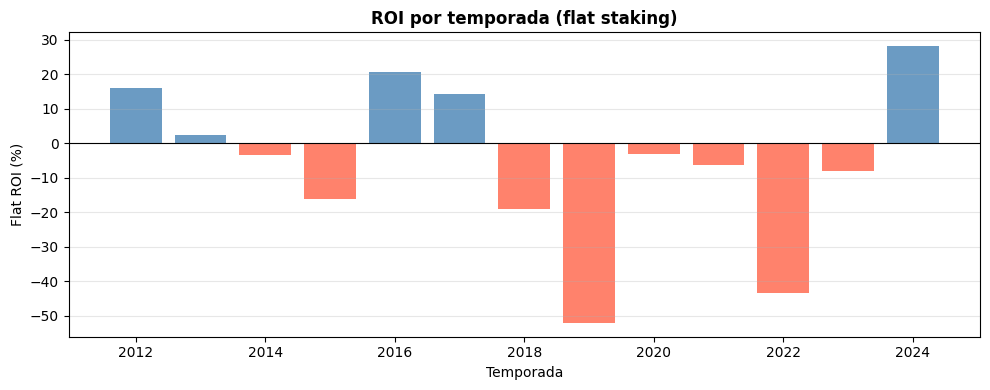

Guardados: results/backtest_master_bets.csv y backtest_master_seasons.csv


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['steelblue' if r > 0 else 'tomato' for r in df_seasons['Flat_ROI']]
ax.bar(df_seasons['Season'].astype(int), df_seasons['Flat_ROI']*100, color=colors, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Temporada'); ax.set_ylabel('Flat ROI (%)'); ax.grid(axis='y', alpha=0.3)
ax.set_title('ROI por temporada (flat staking)', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/roi_por_temporada.png', dpi=120, bbox_inches='tight')
plt.show()

# Guardar resultados
df_bets.to_csv('../results/backtest_master_bets.csv', index=False)
df_seasons.to_csv('../results/backtest_master_seasons.csv', index=False)
print('Guardados: results/backtest_master_bets.csv y backtest_master_seasons.csv')
